## Convolutional Neuronal Network am Beispiel des MNIST - Datensatzes

Als Beispiel für ein Fully Connected Neuronal Net (FCNN) wird der MNIST - Datensatz verwendet. Dieser Datensatz besteht aus handgeschriebenen Ziffern (0-9) und ist ein Standard-Datensatz für die Evaluierung von Bildklassifikationsalgorithmen.

In [1]:
#load modules


import numpy as np
import os

import datetime
import matplotlib.pyplot as plt
#--------------------------------------------------
# TensorFlow import
#-------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

import modules.matrixPlotting

##### Laden des MNIST - Datensatzes

Der Datsatz kann direkt über die Bibliothek `tensorflow` geladen werden. Dabei werden die Bilder in Trainings- und Testdaten aufgeteilt. Jedes Bild hat eine Größe von 28x28 Pixeln und ist in Graustufen.

In [2]:
#--------------------------------------------------
# Load MNIST-Datensatzes Dataset using Keras
#--------------------------------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
# Analyze and investigate data Structure
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train.shape}")



Trainingsdaten: (60000, 28, 28), Labels: (60000,)


##### Anzeige der Daten

Jede Ziffer wird einmal angezeigt

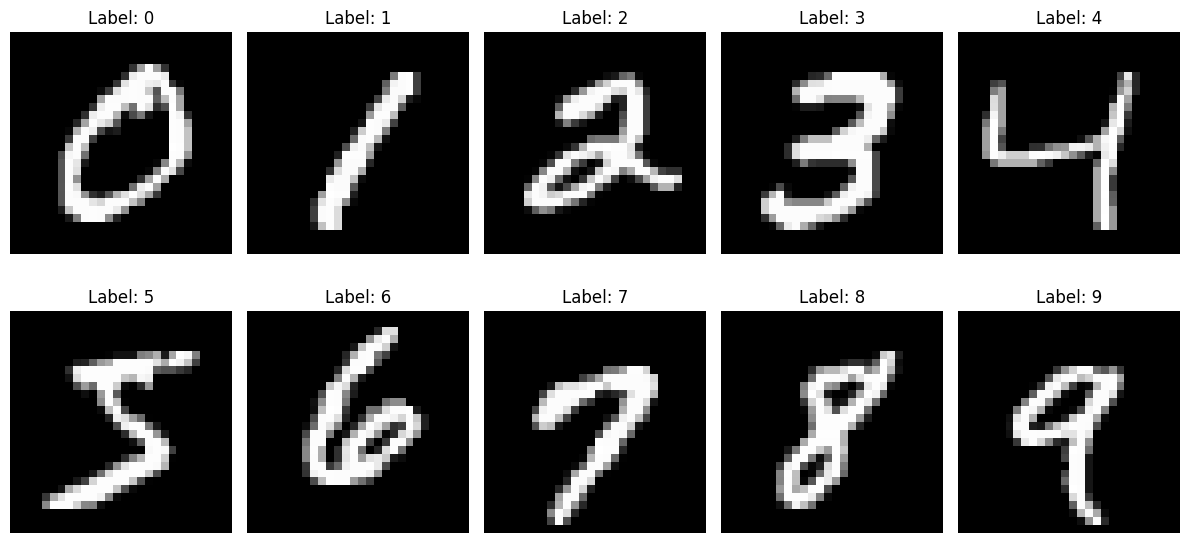

In [4]:
# Create a figure to display the images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel() # Flatten the 2x5 grid into a 1D array

# Loop through each digit from 0 to 9
for i in range(10):
    # Find the first index of the current digit in the training labels
    idx = np.where(y_train == i)[0][0]
    
    # Get the corresponding image from the training data
    image = X_train[idx]
    
    # Display the image on the appropriate subplot
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {i}")
    axes[i].axis('off') # Hide the axes

plt.tight_layout()
plt.show()

##### Vorbereitung der Daten 

Die Daten müssen für die Eingabe in das FCNN vorbereitet werden. Dazu werden die 28x28 Pixel großen Bilder in Vektoren der Länge 784 (28*28) umgewandelt. Außerdem werden die Pixelwerte normalisiert, indem sie durch 255 geteilt werden, um Werte zwischen 0 und 1 zu erhalten.

Die Labels werden in eine One-Hot_Kodieriung umgewandelt. D.h. die Labels (Ziffern 0-9) werden in einen binären Vektor der Länge 10 umgewandelt, wobei die Position der Ziffer auf 1 gesetzt wird und alle anderen Positionen auf 0. Zum Beispiel wird die Ziffer '3' als [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] kodiert.

In [5]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

#--------------------------------------------------
# Flatten
#--------------------------------------------------
# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)



#--------------------------------------------------
# One-Hot-Kodierung
#--------------------------------------------------
y_train_oneHot = tf.keras.utils.to_categorical(y_train, 10)
y_test_oneHot = tf.keras.utils.to_categorical(y_test, 10)

##### Anzeigen der abgewandelten Datenstruktur

In [6]:
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train_oneHot.shape}")

print(f"One-Hot-Encoding: \n {y_train_oneHot[0:10,:]}")

print(f"Beispiel-Bild (Ausschnitt): \n {X_train[55][200:250]}")

Trainingsdaten: (60000, 28, 28, 1), Labels: (60000, 10)
One-Hot-Encoding: 
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
Beispiel-Bild (Ausschnitt): 
 []


In [7]:
#--------------------------------------------------# Define and KERAS / TensorFlow Sequential Model)
#--------------------------------------------------# define initila values initializers
init_kernel = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
init_bias   = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)

model_fcn = Sequential()
model_fcn.add(tf.keras.Input(input_shape))
model_fcn.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu", kernel_initializer = init_kernel, bias_initializer = init_bias))
model_fcn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model_fcn.add(tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu", kernel_initializer = init_kernel, bias_initializer = init_bias))
model_fcn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model_fcn.add(tf.keras.layers.Flatten())
model_fcn.add(tf.keras.layers.Dropout(0.5))
model_fcn.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

model_fcn.summary()

'''
# build the model
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()
'''


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

'\n# build the model\nmodel = keras.Sequential(\n    [\n        keras.Input(shape=input_shape),\n        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),\n        layers.MaxPooling2D(pool_size=(2, 2)),\n        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),\n        layers.MaxPooling2D(pool_size=(2, 2)),\n        layers.Flatten(),\n        layers.Dropout(0.5),\n        layers.Dense(num_classes, activation="softmax"),\n    ]\n)\n\nmodel.summary()\n'

In [8]:
#--------------------------------------------------
# define custom MSE loss function  
#--------------------------------------------------
def my_mse(y_true,y_pred):
    L = tf.reduce_mean(tf.square(tf.subtract(y_true,y_pred)))
    return L

In [9]:
#--------------------------------------------------
# Modell kompilieren
#------------------------------------------------

model_fcn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=['accuracy'])

#--------------------------------------------------
# Modell trainieren
#--------------------------------------------------
history_fcn = model_fcn.fit(X_train, y_train_oneHot, batch_size=128, epochs=20 , validation_split=0.1, verbose=1)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7913 - loss: 6.9591 - val_accuracy: 0.9705 - val_loss: 0.3333
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9234 - loss: 0.7309 - val_accuracy: 0.9768 - val_loss: 0.1370
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9392 - loss: 0.3336 - val_accuracy: 0.9778 - val_loss: 0.0926
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9494 - loss: 0.2101 - val_accuracy: 0.9778 - val_loss: 0.0777
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9548 - loss: 0.1647 - val_accuracy: 0.9820 - val_loss: 0.0648
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9604 - loss: 0.1408 - val_accuracy: 0.9835 - val_loss: 0.0596
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9646 - loss: 0.1228 - val_accuracy: 0.9827 - val_loss: 0.0573
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9678 - loss: 0.1107 - val_accuracy:

------------------------------------------
Klassifikationsgenauigkeit (Trainingsende)
------------------------------------------
97.78333306312561  Prozent


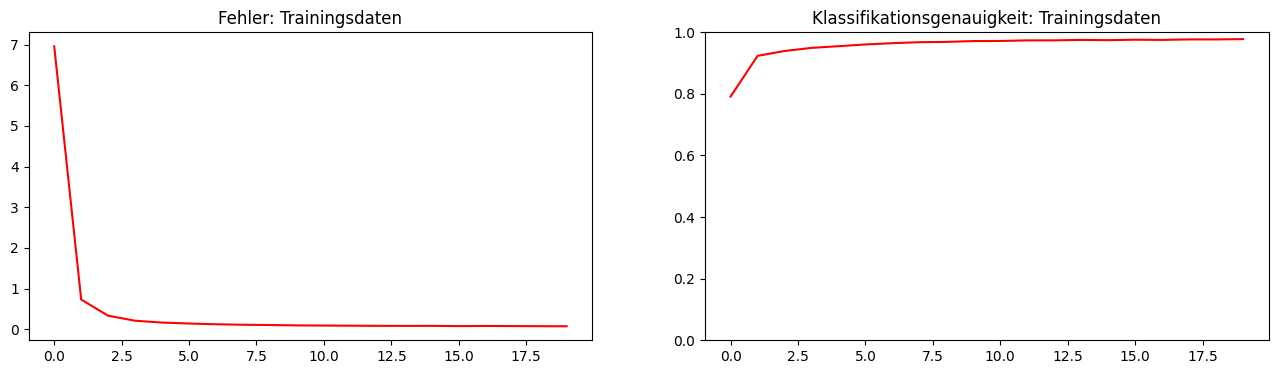

In [10]:
fig, ax = plt.subplots(1,2, squeeze=False,figsize=(16, 4))

ax[0,0].plot(history_fcn.history['loss'],"r")
ax[0,1].plot(history_fcn.history['accuracy'],"r")
ax[0,1].set_ylim([0,1])


ax[0,0].set_title("Fehler: Trainingsdaten")
t=ax[0,1].set_title("Klassifikationsgenauigkeit: Trainingsdaten")

print("------------------------------------------")
print("Klassifikationsgenauigkeit (Trainingsende)")
print("------------------------------------------")
print(np.max(history_fcn.history['accuracy'])*100 , " Prozent")

In [11]:
# klassifikation auf Testdaten durchführen
test_loss, test_accuracy = model_fcn.evaluate(X_test, y_test_oneHot, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9847 - loss: 0.0562


In [12]:
print("------------------------------------------")
print("Klassifikationsgenauigkeit Testdate )")
print("------------------------------------------")
print(test_accuracy*100 , " Prozent")


------------------------------------------
Klassifikationsgenauigkeit Testdate )
------------------------------------------
98.47000241279602  Prozent


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


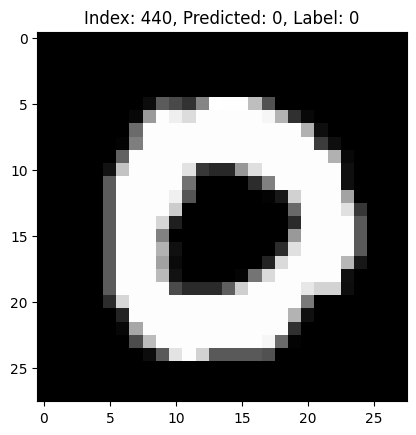

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


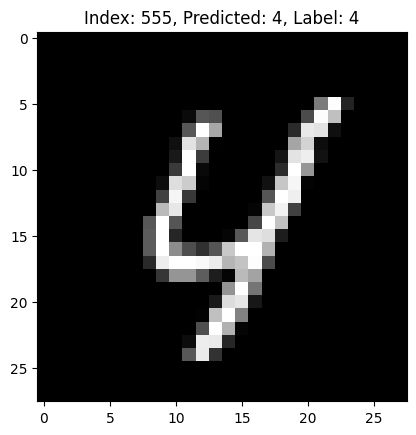

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


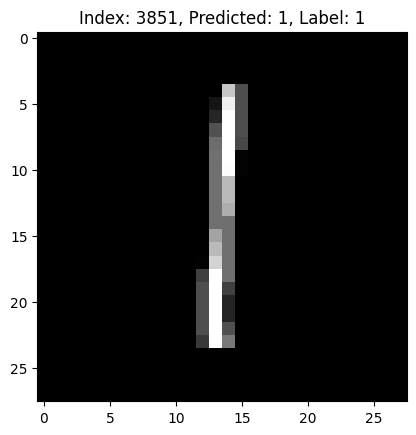

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


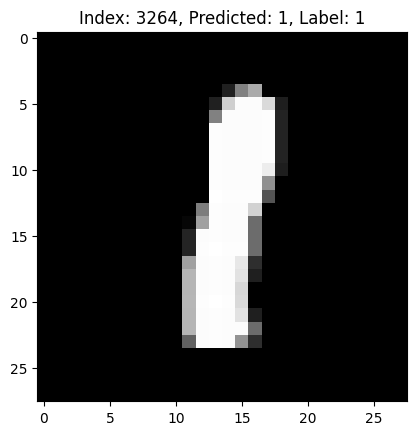

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


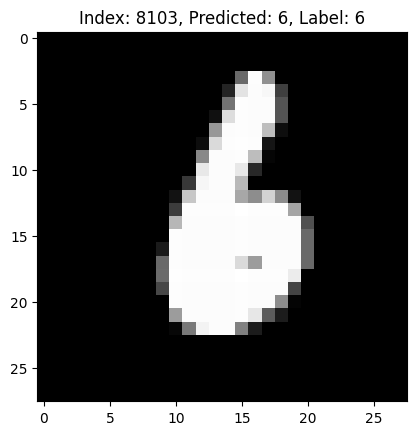

In [13]:
# 10 random numbers from test set
random_indices = np.random.randint(0, X_test.shape[0], size=5)

for index in random_indices:
    example_image = X_test[index].reshape(-1, 28, 28, 1)
    example_label = y_test[index]
    example_prediction = model_fcn.predict(example_image)
    predicted_label = int(np.dot(y_test_oneHot[index], np.array([0,1,2,3,4,5,6,7,8,9])))

    #print(f'index {index}')
    #print(f'predicted {predicted_label}')
    #print(f'actual {example_label}')

    plt.figure()
    plt.imshow(example_image.reshape(28,28), cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {example_label}')
    plt.show()


In [14]:
# identify and print misclassified examples
predictions = model_fcn.predict(X_test.reshape(-1, 28, 28, 1))
predicted_labels = np.argmax(predictions, axis=1)
misclassified_indices = np.where(predicted_labels != y_test)[0]
print(f'Anzahl falsch klassifizierter Objekte: {misclassified_indices.shape}')
print(predictions.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Anzahl falsch klassifizierter Objekte: (153,)
(10000, 10)


Falsche Klassifizierungen: 153
[ 43  98 107 152 114 124  46  45  97  43]
[1813 4536 4814 9905 5937 6400 2018 1941 4500 1813]


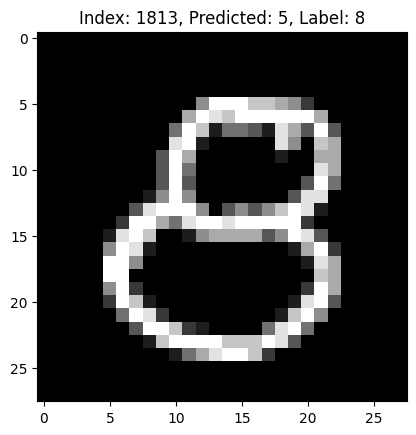

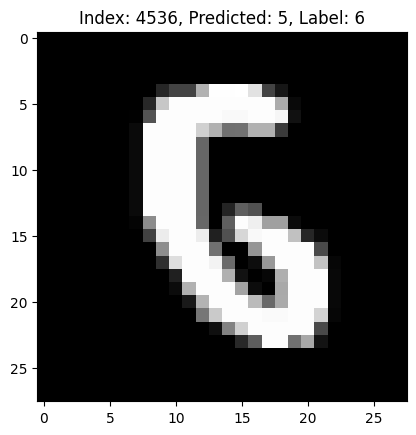

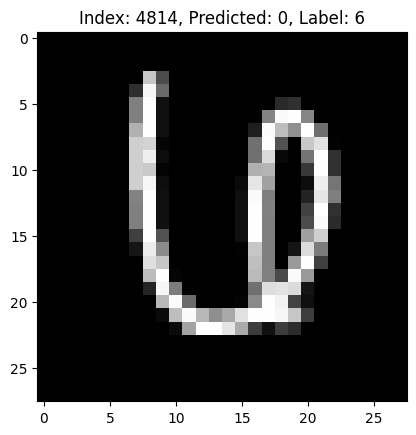

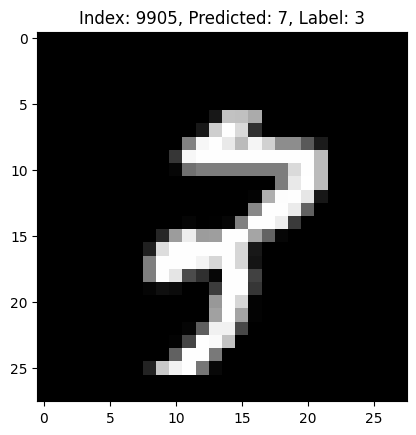

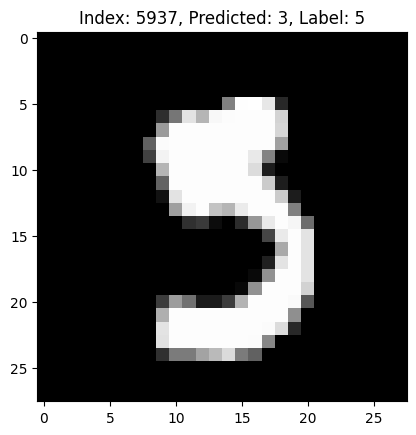

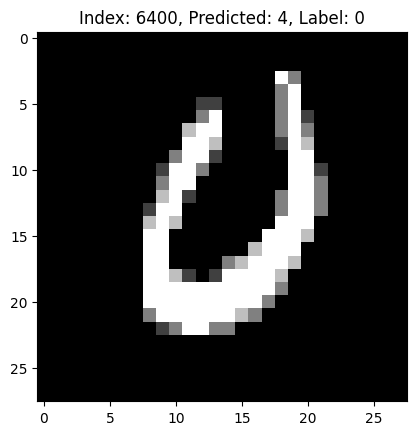

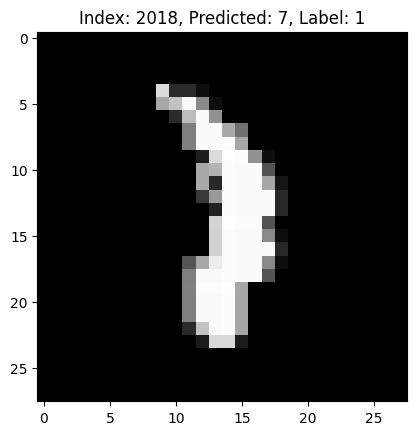

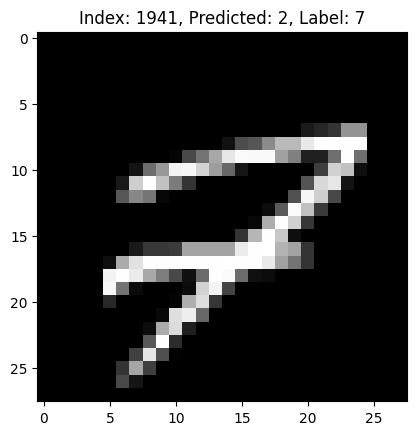

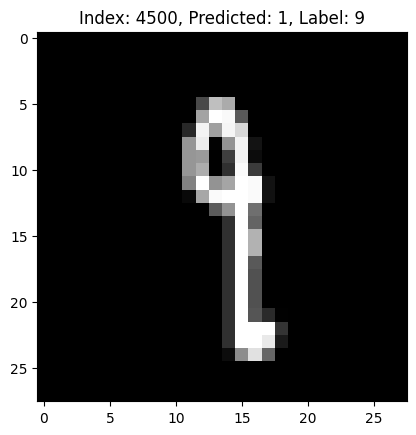

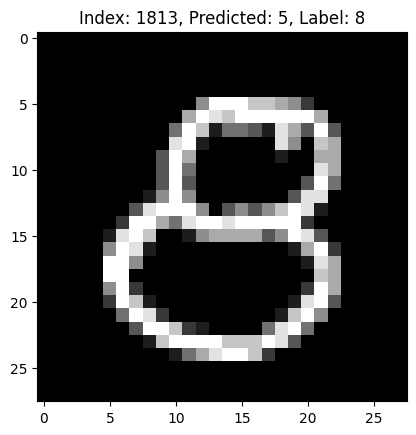

In [15]:
print(f'Falsche Klassifizierungen: {misclassified_indices.shape[0]}')


# print number of misclassified examples
indices = np.random.randint(0, misclassified_indices.shape[0], size=10)
print(indices)
indices = misclassified_indices[indices]
print(indices)



for index in indices:
    example_image = X_test[index].reshape(-1, 28, 28, 1)
    predicted_label = predicted_labels[index]
    label = y_test[index]

    plt.figure()
    plt.imshow(example_image.reshape(28,28), cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {label}')
    plt.show()

In [16]:
print(predicted_labels.shape)
print(y_test.shape)

(10000,)
(10000,)


In [17]:
cMat_test = tf.math.confusion_matrix(
    predicted_labels,
    y_test,
    num_classes=None,
    weights=None,
    dtype=tf.dtypes.int32,
    name=None
)


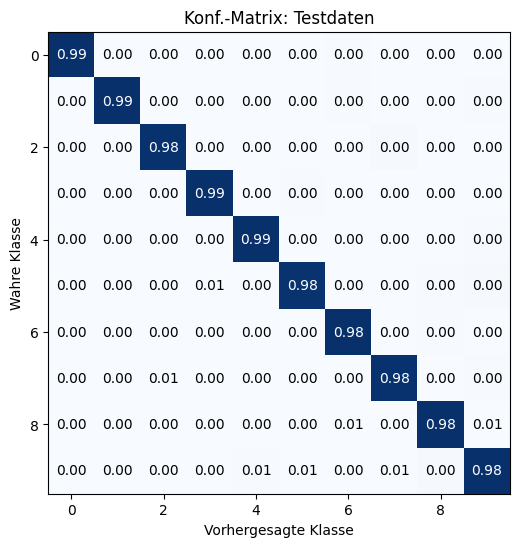

In [18]:
fig, ax_ = plt.subplots(1,1, squeeze=False,figsize=(6, 6))
#----------------------------------
# Konfusionsmatrix ausgeben
#----------------------------------
modules.matrixPlotting.plotConfusionMatrix(cMat_test,  True, ax_[0,0],txt="Konf.-Matrix: Testdaten") 